# Столбчатые диаграммы

In [40]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [41]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [42]:
query = """
SELECT strftime('%Y-%m-%d', timestamp) AS day,
       CAST(strftime('%H', timestamp) AS INTEGER) AS hour
FROM checker
WHERE uid LIKE 'user_%'
"""

df = pd.read_sql(query, conn)
df

,day,hour
0,2020-04-17,5
1,2020-04-17,5
2,2020-04-17,5
3,2020-04-17,5
4,2020-04-17,5
...,...,...
3202,2020-05-21,20
3203,2020-05-21,20
3204,2020-05-21,20
3205,2020-05-21,20


In [43]:
df['day'] = pd.to_datetime(df['day'])
df['hour'] = df['hour'].astype(int)
df

,day,hour
0,2020-04-17,5
1,2020-04-17,5
2,2020-04-17,5
3,2020-04-17,5
4,2020-04-17,5
...,...,...
3202,2020-05-21,20
3203,2020-05-21,20
3204,2020-05-21,20
3205,2020-05-21,20


In [44]:
df['is_weekend'] = df['day'].dt.dayofweek >= 5

In [45]:
per_day = df.groupby(['is_weekend', 'day', 'hour']).size().reset_index(name='commits')
per_day

,is_weekend,day,hour,commits
0,False,2020-04-17,5,13
1,False,2020-04-17,11,8
2,False,2020-04-17,12,2
3,False,2020-04-20,11,2
4,False,2020-04-20,14,3
...,...,...,...,...
283,True,2020-05-17,18,3
284,True,2020-05-17,19,8
285,True,2020-05-17,20,2
286,True,2020-05-17,21,12


In [46]:
average_commits = per_day.groupby(['is_weekend', 'hour'])['commits'].mean()
average_commits

is_weekend  hour
False       0        3.000000
            3        2.000000
            5        7.500000
            6        1.500000
            7        5.166667
            8        3.700000
            9        6.000000
            10      13.200000
            11       6.769231
            12       7.181818
            13       8.111111
            14      10.166667
            15      12.818182
            16      18.888889
            17      16.000000
            18      15.181818
            19      17.833333
            20      14.076923
            21      24.333333
            22       3.750000
            23       5.000000
True        0        2.000000
            1        6.000000
            3        1.000000
            5        2.000000
            7        4.000000
            8        7.000000
            9        3.666667
            10       7.000000
            11      23.600000
            12       9.500000
            13      18.000000
            14      12.

In [47]:
hours = pd.RangeIndex(24, name='hour')
weekend = average_commits.xs(True, level='is_weekend').reindex(hours)
working = average_commits.xs(False, level='is_weekend').reindex(hours)

In [48]:
pd.DataFrame({'working_day': working, 'weekend': weekend})

,working_day,weekend
hour,,
0,3.000000,2.000000
1,NaN,6.000000
2,NaN,NaN
3,2.000000,1.000000
4,NaN,NaN
5,7.500000,2.000000
6,1.500000,NaN
7,5.166667,4.000000
8,3.700000,7.000000


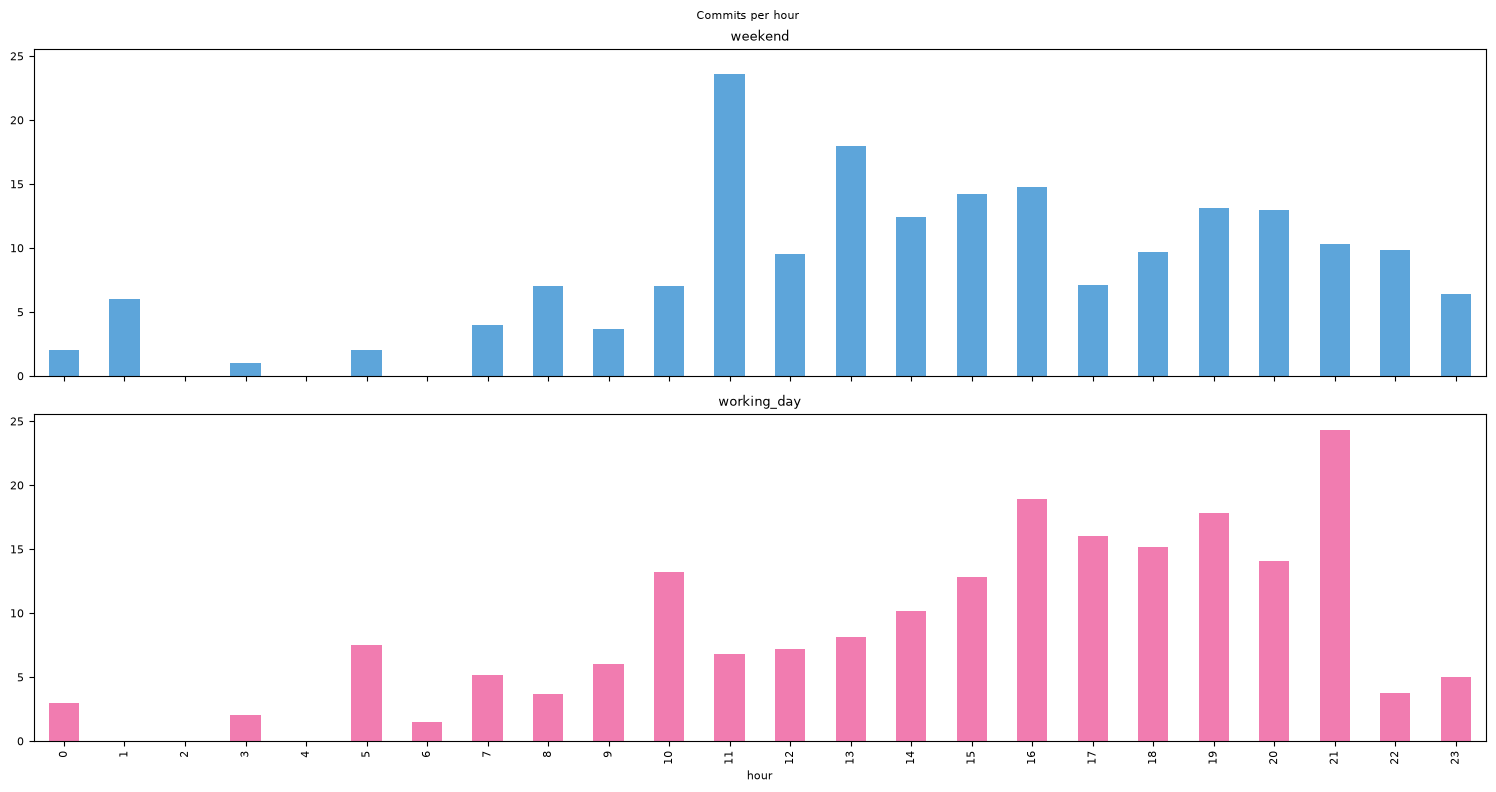

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, sharey=True)

weekend.plot(kind='bar', ax=axes[0], color='#5DA5DA',
             label='weekend', title='weekend', fontsize=8)

working.plot(kind='bar', ax=axes[1], color='#F17CB0',
             label='working_day', title='working_day', fontsize=8)

fig.suptitle('Commits per hour', fontsize=8)
axes[1].set_xlabel('hour', fontsize=8)

plt.tight_layout()
plt.show()

«Различается ли динамика в рабочие дни и в выходные?»

Да. Наибольшее среднее число коммитов в будни — в 21:00, а в выходные — в 11:00.